### Analyse du data :

In [92]:
# 1- charge de donnees:
import importlib
import pipeline
importlib.reload(pipeline)
from pipeline import train_with_grid_search

import pandas as pd

df = pd.read_csv('./data/data_sante.csv')
data = df.copy()
data.head()
 


,age,gender,status,pressurehight,pressurelow,glucose,kcm,troponin,impluse
0,64,1,negative,160,83,160.0,1.80,0.012,66
1,21,1,positive,98,46,296.0,6.75,1.060,94
2,55,1,negative,160,77,270.0,1.99,0.003,64
3,64,1,positive,120,55,270.0,13.87,0.122,70
4,55,1,negative,112,65,300.0,1.08,0.003,64


In [74]:
data.duplicated().sum()

np.int64(0)

In [75]:
# 2- verification de nombre des lignes et des colonnes :
print("shape:", data.shape)

shape: (1319, 9)


In [76]:
# 3- information general du data:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   status         1319 non-null   object 
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   impluse        1319 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [77]:
data.isnull().sum()

age              0
gender           0
status           0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
impluse          0
dtype: int64

In [78]:
# 4- les statistique descriptive:
data.describe()

,age,gender,pressurehight,pressurelow,glucose,kcm,troponin,impluse
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,127.170584,72.269143,146.634344,15.274306,0.360942,78.336619
std,13.647315,0.474027,26.122720,14.033924,74.923045,46.327083,1.154568,51.630270
min,14.000000,0.000000,42.000000,38.000000,35.000000,0.321000,0.001000,20.000000
25%,47.000000,0.000000,110.000000,62.000000,98.000000,1.655000,0.006000,64.000000
50%,58.000000,1.000000,124.000000,72.000000,116.000000,2.850000,0.014000,74.000000
75%,65.000000,1.000000,143.000000,81.000000,169.500000,5.805000,0.085500,85.000000
max,103.000000,1.000000,223.000000,154.000000,541.000000,300.000000,10.300000,1111.000000


In [79]:
# 5- types :
data.dtypes

age                int64
gender             int64
status            object
pressurehight      int64
pressurelow        int64
glucose          float64
kcm              float64
troponin         float64
impluse            int64
dtype: object

### Visualisation :

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data['status'] = data['status'].apply(lambda x: 1 if x == 'positive' else 0)
data['status']

0       0
1       1
2       0
3       1
4       0
       ..
1314    0
1315    1
1316    1
1317    1
1318    1
Name: status, Length: 1319, dtype: int64

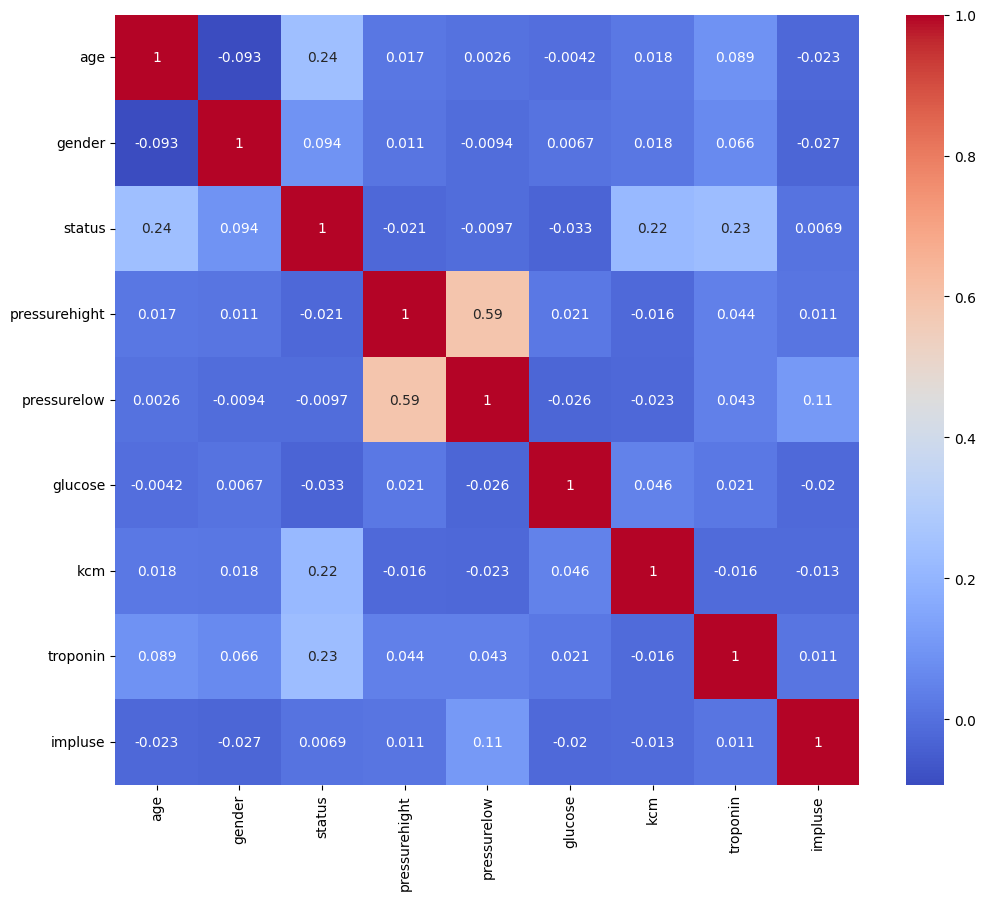

In [81]:
correlation_matrix = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()


In [82]:
# Check for data is balanced

data["status"].value_counts()

status
1    810
0    509
Name: count, dtype: int64

<Axes: xlabel='status', ylabel='count'>

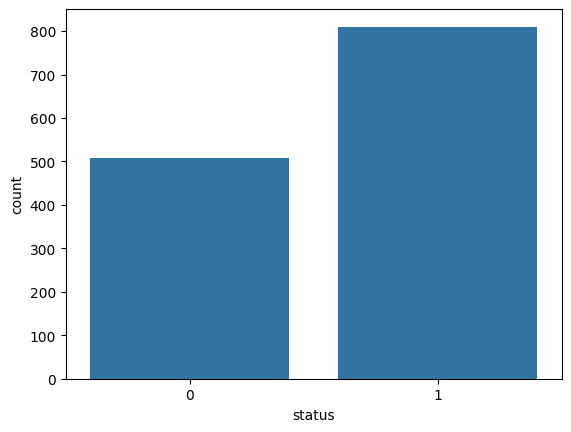

In [ ]:
sns.countplot(x=data["status"], data=data)
 

In [84]:
data.columns

Index(['age', 'gender', 'status', 'pressurehight', 'pressurelow', 'glucose',
       'kcm', 'troponin', 'impluse'],
      dtype='object')

In [89]:
num_list = [
    "age",
    "gender",
    "pressurehight",
    "pressurelow",
    "glucose",
    "kcm",
    "troponin",
    "impluse",
]

In [86]:


accuracy, precision, recall, f1 = train_with_grid_search("random_forest", num_list, data)

print(accuracy)
print(precision)
print(recall)
print(f1)

0.9810606060606061
0.9817073170731707
0.9877300613496932
0.9847094801223242


In [87]:
accuracy, precision, recall, f1 = train_with_grid_search("knn", num_list, data)

print(accuracy)
print(precision)
print(recall)
print(f1)

0.8446969696969697
0.9013157894736842
0.8404907975460123
0.8698412698412699
